# Multi-Class Prediction of Obesity Risk — Required Models

This notebook is designed for the Kaggle **Multi-Class Prediction of Obesity Risk** competition, also known as Playground Series Season 4, Episode 2. It builds and interprets four required classification models:

1. Multinomial Logistic Regression  
2. Linear Discriminant Analysis  
3. Gaussian Naïve Bayes  
4. Support Vector Machine  

The target variable is `NObeyesdad`, a seven-class obesity-risk label. The notebook includes exploratory analysis, preprocessing, model training, cross-validation, validation-set evaluation, assumption checks, interpretation, and a Kaggle submission file.


## 1. Import Libraries

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
RANDOM_STATE = 42


## 2. Load Kaggle Data

Run this notebook inside Kaggle or place `train.csv`, `test.csv`, and `sample_submission.csv` in the same folder as the notebook.


In [3]:
# Common Kaggle input path for Playground Series S4E2
kaggle_path = Path("/kaggle/input/competitions/playground-series-s4e2") 
local_path = Path(".")

if (kaggle_path / "train.csv").exists():
    DATA_PATH = kaggle_path
else:
    DATA_PATH = local_path

train = pd.read_csv(DATA_PATH / "train.csv")
test = pd.read_csv(DATA_PATH / "test.csv")
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())


Train shape: (20758, 18)
Test shape: (13840, 17)
Sample submission shape: (13840, 2)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,20758,Male,26.899886,1.848294,120.644178,yes,yes,2.938616,3.000000,Sometimes,no,2.825629,no,0.855400,0.000000,Sometimes,Public_Transportation
1,20759,Female,21.000000,1.600000,66.000000,yes,yes,2.000000,1.000000,Sometimes,no,3.000000,no,1.000000,0.000000,Sometimes,Public_Transportation
2,20760,Female,26.000000,1.643355,111.600553,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.250502,Sometimes,Public_Transportation
3,20761,Male,20.979254,1.553127,103.669116,yes,yes,2.000000,2.977909,Sometimes,no,2.786417,no,0.094851,0.000000,Sometimes,Public_Transportation
4,20762,Female,26.000000,1.627396,104.835346,yes,yes,3.000000,3.000000,Sometimes,no,2.653531,no,0.000000,0.741069,Sometimes,Public_Transportation


## 3. Data Overview and Target Distribution

Columns:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Missing values in training data:


id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


Missing values in test data:


id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
dtype: int64


Target distribution:


NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64

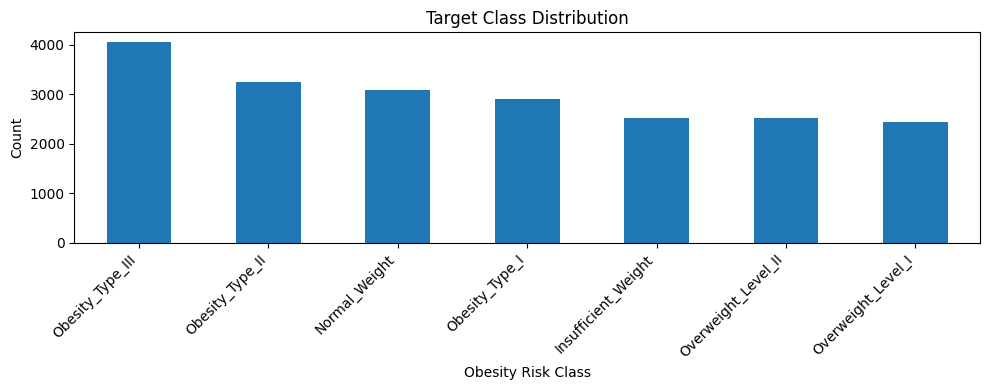


Basic summary of numeric features:


,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


In [4]:
target_col = "NObeyesdad"
id_col = "id"

print("Columns:")
print(train.columns.tolist())

print("\nMissing values in training data:")
display(train.isna().sum().sort_values(ascending=False))

print("\nMissing values in test data:")
display(test.isna().sum().sort_values(ascending=False))

print("\nTarget distribution:")
target_counts = train[target_col].value_counts()
display(target_counts)

fig, ax = plt.subplots(figsize=(10, 4))
target_counts.plot(kind="bar", ax=ax)
ax.set_title("Target Class Distribution")
ax.set_xlabel("Obesity Risk Class")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nBasic summary of numeric features:")
display(train.select_dtypes(include=np.number).describe())


## 4. Feature Engineering

BMI is added because height and weight are directly related to obesity risk. The model also keeps the original height and weight variables because they may contain additional information.


In [5]:
def add_features(df):
    df = df.copy()
    if {"Weight", "Height"}.issubset(df.columns):
        df["BMI"] = df["Weight"] / (df["Height"] ** 2)
    if {"Age", "BMI"}.issubset(df.columns):
        df["Age_BMI"] = df["Age"] * df["BMI"]
    return df

train_fe = add_features(train)
test_fe = add_features(test)

X = train_fe.drop(columns=[target_col])
y = train_fe[target_col]

if id_col in X.columns:
    X = X.drop(columns=[id_col])

X_test_final = test_fe.drop(columns=[id_col], errors="ignore")

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Numeric features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI', 'Age_BMI']


## 5. Assumption Investigation

These checks do not determine whether a model can be used, but they help interpret whether each model's assumptions are realistic.

- **Multinomial logistic regression:** assumes independent observations, no severe multicollinearity, and a linear relationship between predictors and log-odds after encoding/scaling.
- **LDA:** assumes approximately multivariate normal predictors within each class and similar covariance matrices across classes.
- **Naïve Bayes:** assumes conditional independence of predictors given the class.
- **SVM:** does not require normality, but it is sensitive to feature scale and hyperparameter choices.


,proportion
NObeyesdad,
Obesity_Type_III,0.194913
Obesity_Type_II,0.156470
Normal_Weight,0.148473
Obesity_Type_I,0.140187
Insufficient_Weight,0.121544
Overweight_Level_II,0.121495
Overweight_Level_I,0.116919


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,Age_BMI
Age,1.000000,-0.011713,0.283381,0.034414,-0.048479,-0.016325,-0.192259,-0.296154,0.320842,0.790253
Height,-0.011713,1.000000,0.416677,-0.071546,0.191383,0.183706,0.295278,0.076433,0.098126,0.047385
Weight,0.283381,0.416677,1.000000,0.245682,0.095947,0.317914,-0.084845,-0.086471,0.941071,0.761192
FCVC,0.034414,-0.071546,0.245682,1.000000,0.113349,0.101299,-0.089822,-0.147843,0.296933,0.216569
NCP,-0.048479,0.191383,0.095947,0.113349,1.000000,0.080949,0.100871,0.067459,0.048736,0.016392
CH2O,-0.016325,0.183706,0.317914,0.101299,0.080949,1.000000,0.082932,-0.010654,0.292142,0.168896
FAF,-0.192259,0.295278,-0.084845,-0.089822,0.100871,0.082932,1.000000,0.021213,-0.210239,-0.261389
TUE,-0.296154,0.076433,-0.086471,-0.147843,0.067459,-0.010654,0.021213,1.000000,-0.117098,-0.251729
BMI,0.320842,0.098126,0.941071,0.296933,0.048736,0.292142,-0.210239,-0.117098,1.000000,0.824854
Age_BMI,0.790253,0.047385,0.761192,0.216569,0.016392,0.168896,-0.261389,-0.251729,0.824854,1.000000


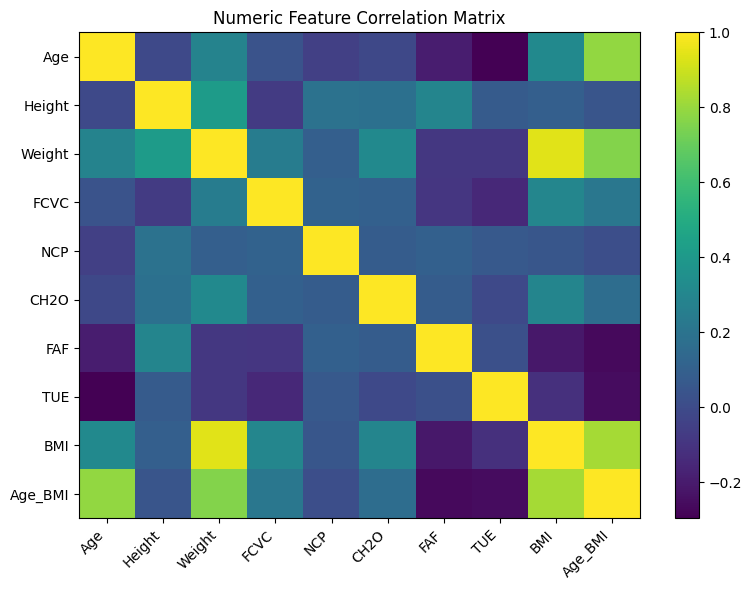

,feature,R2_against_other_numeric_features,VIF
8,BMI,0.993953,165.375103
2,Weight,0.992352,130.756687
9,Age_BMI,0.989136,92.050578
0,Age,0.969158,32.423714
1,Height,0.934194,15.196293
6,FAF,0.195846,1.243544
5,CH2O,0.145594,1.170403
3,FCVC,0.136797,1.158476
7,TUE,0.125149,1.143052
4,NCP,0.094361,1.104193


In [6]:
# 5.1 Class balance
class_balance = y.value_counts(normalize=True).rename("proportion").to_frame()
display(class_balance)

# 5.2 Numeric correlations and possible multicollinearity
corr = train_fe[numeric_features].corr()
display(corr)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Numeric Feature Correlation Matrix")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# 5.3 VIF for numeric features
def calculate_vif(df_numeric):
    # Uses linear regression R^2 to compute VIF without requiring statsmodels.
    vif_rows = []
    clean = df_numeric.dropna().copy()
    for col in clean.columns:
        other_cols = [c for c in clean.columns if c != col]
        if not other_cols:
            continue
        X_other = clean[other_cols].values
        y_col = clean[col].values
        X_other = np.column_stack([np.ones(len(X_other)), X_other])
        try:
            beta = np.linalg.lstsq(X_other, y_col, rcond=None)[0]
            pred = X_other @ beta
            ss_res = np.sum((y_col - pred) ** 2)
            ss_tot = np.sum((y_col - y_col.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            vif = 1 / (1 - r2) if r2 < 1 else np.inf
        except Exception:
            vif = np.nan
            r2 = np.nan
        vif_rows.append({"feature": col, "R2_against_other_numeric_features": r2, "VIF": vif})
    return pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)

vif_table = calculate_vif(train_fe[numeric_features])
display(vif_table)


In [7]:
# 5.4 Normality checks by class for LDA
# Shapiro-Wilk is sensitive for large samples, so this samples up to 500 observations per class.
normality_rows = []
for cls in sorted(y.unique()):
    cls_data = train_fe.loc[y == cls, numeric_features]
    for col in numeric_features:
        sample = cls_data[col].dropna()
        if len(sample) > 500:
            sample = sample.sample(500, random_state=RANDOM_STATE)
        if len(sample) >= 3:
            stat, p = stats.shapiro(sample)
            normality_rows.append({"class": cls, "feature": col, "shapiro_stat": stat, "p_value": p})
normality_table = pd.DataFrame(normality_rows)
display(normality_table.sort_values("p_value").head(20))

# 5.5 Covariance similarity check for LDA
# This is a practical diagnostic using log determinants by class.
cov_rows = []
for cls in sorted(y.unique()):
    cls_num = train_fe.loc[y == cls, numeric_features].dropna()
    cov = np.cov(cls_num.values, rowvar=False)
    cov = cov + np.eye(cov.shape[0]) * 1e-8
    sign, logdet = np.linalg.slogdet(cov)
    cov_rows.append({"class": cls, "log_determinant_covariance": logdet})
cov_table = pd.DataFrame(cov_rows)
display(cov_table)

print("Interpretation guide:")
print("- Very small Shapiro p-values indicate numeric predictors are not normally distributed within classes.")
print("- Large differences in covariance log determinants suggest LDA's equal-covariance assumption is imperfect.")


,class,feature,shapiro_stat,p_value
14,Normal_Weight,NCP,0.495074,2.638084e-35
34,Obesity_Type_II,NCP,0.506319,5.161518e-35
9,Insufficient_Weight,Age_BMI,0.633006,2.708043e-31
23,Obesity_Type_I,FCVC,0.653114,1.302337e-30
64,Overweight_Level_II,NCP,0.680290,1.225136e-29
24,Obesity_Type_I,NCP,0.683783,1.651973e-29
13,Normal_Weight,FCVC,0.696369,4.958905e-29
40,Obesity_Type_III,Age,0.703646,9.517392e-29
63,Overweight_Level_II,FCVC,0.710844,1.836681e-28
46,Obesity_Type_III,FAF,0.720140,4.376435e-28


,class,log_determinant_covariance
0,Insufficient_Weight,-4.612531
1,Normal_Weight,-2.122835
2,Obesity_Type_I,1.227631
3,Obesity_Type_II,-5.305455
4,Obesity_Type_III,-37.413750
5,Overweight_Level_I,-0.242560
6,Overweight_Level_II,-1.059614


Interpretation guide:
- Very small Shapiro p-values indicate numeric predictors are not normally distributed within classes.
- Large differences in covariance log determinants suggest LDA's equal-covariance assumption is imperfect.


In [8]:
# 5.6 Naive Bayes conditional independence diagnostic
# We inspect numeric correlations within each class. Strong correlations indicate the NB independence assumption is violated.
nb_corr_rows = []
for cls in sorted(y.unique()):
    cls_num = train_fe.loc[y == cls, numeric_features]
    cls_corr = cls_num.corr().abs()
    upper_vals = cls_corr.where(np.triu(np.ones(cls_corr.shape), k=1).astype(bool)).stack()
    nb_corr_rows.append({
        "class": cls,
        "mean_abs_pairwise_numeric_corr": upper_vals.mean(),
        "max_abs_pairwise_numeric_corr": upper_vals.max()
    })
nb_corr_table = pd.DataFrame(nb_corr_rows)
display(nb_corr_table)

print("Interpretation guide:")
print("- Naive Bayes assumes predictors are conditionally independent within each class.")
print("- Larger within-class correlations show that this assumption is not fully satisfied, which is common in real data.")


,class,mean_abs_pairwise_numeric_corr,max_abs_pairwise_numeric_corr
0,Insufficient_Weight,0.230649,0.849387
1,Normal_Weight,0.133950,0.872619
2,Obesity_Type_I,0.204509,0.963936
3,Obesity_Type_II,0.170969,0.936885
4,Obesity_Type_III,0.392132,0.867204
5,Overweight_Level_I,0.158271,0.966679
6,Overweight_Level_II,0.143260,0.975796


Interpretation guide:
- Naive Bayes assumes predictors are conditionally independent within each class.
- Larger within-class correlations show that this assumption is not fully satisfied, which is common in real data.


## 6. Preprocessing Pipelines

The same preprocessing is used for all four required models: numeric variables are imputed and standardized, while categorical variables are imputed and one-hot encoded.


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Train/validation split for interpretable holdout performance
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training split:", X_train.shape)
print("Validation split:", X_valid.shape)


Training split: (16606, 18)
Validation split: (4152, 18)


## 7. Build the Four Required Models

In [10]:
models = {
    "Multinomial Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            max_iter=3000,
            C=1.0,
            random_state=RANDOM_STATE
        ))
    ]),
    "Linear Discriminant Analysis": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ]),
    "Gaussian Naive Bayes": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", GaussianNB())
    ]),
    "Support Vector Machine": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", SVC(
            kernel="rbf",
            C=3.0,
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ])
}

models


{'Multinomial Logistic Regression': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Age', 'Height', 'Weight',
                                                    'FCVC', 'NCP', 'CH2O', 'FAF',
                                                    'TUE', 'BMI', 'Age_BMI']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                       

## 8. Cross-Validation and Holdout Evaluation

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
fitted_models = {}

for name, pipe in models.items():
    print(f"\nRunning cross-validation for: {name}")
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy"],
        n_jobs=-1,
        return_train_score=True
    )

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    valid_pred = pipe.predict(X_valid)
    valid_acc = accuracy_score(y_valid, valid_pred)

    cv_rows.append({
        "Model": name,
        "CV Train Accuracy Mean": scores["train_accuracy"].mean(),
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "Validation Accuracy": valid_acc
    })

results = pd.DataFrame(cv_rows).sort_values("Validation Accuracy", ascending=False)
display(results)



Running cross-validation for: Multinomial Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


Running cross-validation for: Linear Discriminant Analysis

Running cross-validation for: Gaussian Naive Bayes

Running cross-validation for: Support Vector Machine


,Model,CV Train Accuracy Mean,CV Accuracy Mean,CV Accuracy Std,Validation Accuracy
3,Support Vector Machine,0.914203,0.881850,0.003807,0.888969
0,Multinomial Logistic Regression,0.866901,0.864386,0.004813,0.871869
1,Linear Discriminant Analysis,0.840058,0.837589,0.004799,0.841040
2,Gaussian Naive Bayes,0.664940,0.664097,0.003891,0.667148


In [12]:
# Classification report and confusion matrix for each model
for name, pipe in fitted_models.items():
    print("\n" + "="*90)
    print(name)
    print("="*90)
    pred = pipe.predict(X_valid)
    print("Validation accuracy:", accuracy_score(y_valid, pred))
    print("\nClassification report:")
    print(classification_report(y_valid, pred))

    cm = pd.DataFrame(
        confusion_matrix(y_valid, pred, labels=pipe.classes_),
        index=[f"Actual: {c}" for c in pipe.classes_],
        columns=[f"Predicted: {c}" for c in pipe.classes_]
    )
    display(cm)



Multinomial Logistic Regression
Validation accuracy: 0.871868978805395

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.95      0.92       505
      Normal_Weight       0.87      0.82      0.85       617
     Obesity_Type_I       0.81      0.85      0.83       582
    Obesity_Type_II       0.94      0.96      0.95       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.76      0.71      0.73       485
Overweight_Level_II       0.74      0.72      0.73       504

           accuracy                           0.87      4152
          macro avg       0.86      0.86      0.86      4152
       weighted avg       0.87      0.87      0.87      4152



,Predicted: Insufficient_Weight,Predicted: Normal_Weight,Predicted: Obesity_Type_I,Predicted: Obesity_Type_II,Predicted: Obesity_Type_III,Predicted: Overweight_Level_I,Predicted: Overweight_Level_II
Actual: Insufficient_Weight,479,25,0,0,0,1,0
Actual: Normal_Weight,56,506,2,0,0,44,9
Actual: Obesity_Type_I,1,0,492,35,4,10,40
Actual: Obesity_Type_II,0,0,23,626,0,0,1
Actual: Obesity_Type_III,0,0,0,1,807,1,0
Actual: Overweight_Level_I,1,46,15,0,0,346,77
Actual: Overweight_Level_II,0,2,76,7,0,55,364



Linear Discriminant Analysis
Validation accuracy: 0.8410404624277457

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.96      0.90       505
      Normal_Weight       0.87      0.74      0.80       617
     Obesity_Type_I       0.79      0.79      0.79       582
    Obesity_Type_II       0.91      0.94      0.92       650
   Obesity_Type_III       0.98      0.98      0.98       809
 Overweight_Level_I       0.70      0.68      0.69       485
Overweight_Level_II       0.69      0.70      0.70       504

           accuracy                           0.84      4152
          macro avg       0.83      0.83      0.83      4152
       weighted avg       0.84      0.84      0.84      4152



,Predicted: Insufficient_Weight,Predicted: Normal_Weight,Predicted: Obesity_Type_I,Predicted: Obesity_Type_II,Predicted: Obesity_Type_III,Predicted: Overweight_Level_I,Predicted: Overweight_Level_II
Actual: Insufficient_Weight,486,18,0,0,0,1,0
Actual: Normal_Weight,90,457,1,0,0,55,14
Actual: Obesity_Type_I,1,1,462,49,9,12,48
Actual: Obesity_Type_II,0,0,33,608,5,0,4
Actual: Obesity_Type_III,0,0,2,10,796,1,0
Actual: Overweight_Level_I,3,46,15,0,0,329,92
Actual: Overweight_Level_II,0,6,70,4,0,70,354



Gaussian Naive Bayes
Validation accuracy: 0.6671483622350675

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.72      0.94      0.81       505
      Normal_Weight       0.74      0.49      0.59       617
     Obesity_Type_I       0.41      0.44      0.43       582
    Obesity_Type_II       0.56      0.96      0.71       650
   Obesity_Type_III       0.96      1.00      0.98       809
 Overweight_Level_I       0.67      0.31      0.43       485
Overweight_Level_II       0.57      0.31      0.40       504

           accuracy                           0.67      4152
          macro avg       0.66      0.64      0.62      4152
       weighted avg       0.68      0.67      0.65      4152



,Predicted: Insufficient_Weight,Predicted: Normal_Weight,Predicted: Obesity_Type_I,Predicted: Obesity_Type_II,Predicted: Obesity_Type_III,Predicted: Overweight_Level_I,Predicted: Overweight_Level_II
Actual: Insufficient_Weight,475,23,2,0,2,3,0
Actual: Normal_Weight,180,300,60,4,17,34,22
Actual: Obesity_Type_I,1,7,257,268,5,7,37
Actual: Obesity_Type_II,0,0,12,625,0,3,10
Actual: Obesity_Type_III,0,0,1,1,806,1,0
Actual: Overweight_Level_I,8,55,171,43,9,151,48
Actual: Overweight_Level_II,0,21,122,179,1,25,156



Support Vector Machine
Validation accuracy: 0.8889691714836223

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.94      0.93       505
      Normal_Weight       0.87      0.85      0.86       617
     Obesity_Type_I       0.86      0.89      0.87       582
    Obesity_Type_II       0.96      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.77      0.71      0.74       485
Overweight_Level_II       0.77      0.78      0.77       504

           accuracy                           0.89      4152
          macro avg       0.88      0.88      0.88      4152
       weighted avg       0.89      0.89      0.89      4152



,Predicted: Insufficient_Weight,Predicted: Normal_Weight,Predicted: Obesity_Type_I,Predicted: Obesity_Type_II,Predicted: Obesity_Type_III,Predicted: Overweight_Level_I,Predicted: Overweight_Level_II
Actual: Insufficient_Weight,475,29,0,0,0,1,0
Actual: Normal_Weight,40,523,2,0,0,42,10
Actual: Obesity_Type_I,1,0,520,19,3,9,30
Actual: Obesity_Type_II,0,0,17,632,0,0,1
Actual: Obesity_Type_III,0,0,2,1,806,0,0
Actual: Overweight_Level_I,1,47,16,0,0,343,78
Actual: Overweight_Level_II,0,4,50,5,0,53,392


## 9. Model Interpretation

In [13]:
# Helper to get transformed feature names
feature_names = fitted_models["Multinomial Logistic Regression"].named_steps["preprocess"].get_feature_names_out()
feature_names = np.array(feature_names)

# 9.1 Multinomial logistic regression coefficient interpretation
log_model = fitted_models["Multinomial Logistic Regression"].named_steps["model"]
coef_df = pd.DataFrame(log_model.coef_, index=log_model.classes_, columns=feature_names)

print("Top positive logistic regression coefficients by class:")
for cls in coef_df.index:
    display(
        coef_df.loc[cls]
        .sort_values(ascending=False)
        .head(10)
        .rename(f"Top positive coefficients for {cls}")
        .to_frame()
    )

print("Top negative logistic regression coefficients by class:")
for cls in coef_df.index:
    display(
        coef_df.loc[cls]
        .sort_values(ascending=True)
        .head(10)
        .rename(f"Top negative coefficients for {cls}")
        .to_frame()
    )


Top positive logistic regression coefficients by class:


,Top positive coefficients for Insufficient_Weight
CAEC_Frequently,1.358581
MTRANS_Automobile,1.205921
Gender_Male,0.695465
CALC_no,0.649225
family_history_with_overweight_no,0.632297
SMOKE_no,0.538322
Height,0.529789
Age,0.463889
CALC_Sometimes,0.247543
FAF,0.226716


,Top positive coefficients for Normal_Weight
Age,1.934277
CAEC_Always,0.717551
MTRANS_Motorbike,0.678041
Gender_Male,0.624774
family_history_with_overweight_no,0.556106
FAF,0.227930
CALC_no,0.209244
CAEC_Frequently,0.158244
SCC_yes,0.154249
NCP,0.145522


,Top positive coefficients for Obesity_Type_I
BMI,4.534790
Weight,2.670705
Age_BMI,1.471309
Gender_Female,0.755651
MTRANS_Automobile,0.449765
CAEC_no,0.433894
CALC_no,0.371241
CH2O,0.280280
CALC_Frequently,0.279290
CAEC_Always,0.276057


,Top positive coefficients for Obesity_Type_II
Weight,7.598470
BMI,5.820638
Age_BMI,2.755989
Gender_Male,2.088339
family_history_with_overweight_yes,0.993308
MTRANS_Walking,0.878963
SCC_no,0.612490
SMOKE_yes,0.593022
CALC_no,0.465785
CAEC_Always,0.353926


...

,Top negative coefficients for Obesity_Type_I
FCVC,-0.858389
Age,-0.842040
Gender_Male,-0.690798
CALC_Sometimes,-0.585678
CAEC_Frequently,-0.555192
NCP,-0.327049
MTRANS_Walking,-0.260872
MTRANS_Public_Transportation,-0.217195
family_history_with_overweight_no,-0.206026
CAEC_Sometimes,-0.089906


,Top negative coefficients for Obesity_Type_II
Gender_Female,-2.027025
family_history_with_overweight_no,-0.931993
CH2O,-0.767750
CAEC_Frequently,-0.587453
SCC_yes,-0.551176
SMOKE_no,-0.531707
MTRANS_Motorbike,-0.524734
MTRANS_Automobile,-0.423695
NCP,-0.400545
Age,-0.315030


,Top negative coefficients for Obesity_Type_III
Gender_Male,-3.236674
MTRANS_Automobile,-1.906094
Age,-1.448156
CALC_no,-1.125637
FAVC_no,-0.684921
family_history_with_overweight_no,-0.631350
FAF,-0.502757
CAEC_Always,-0.502124
TUE,-0.251042
MTRANS_Motorbike,-0.197781


,Top negative coefficients for Overweight_Level_I
Weight,-3.509620
BMI,-0.929956
SCC_no,-0.716170
CALC_no,-0.599999
FCVC,-0.569987
family_history_with_overweight_yes,-0.537199
MTRANS_Public_Transportation,-0.525041
CAEC_Sometimes,-0.440003
Age,-0.378906
CAEC_Frequently,-0.378199


,Top negative coefficients for Overweight_Level_II
Height,-0.749685
FAVC_yes,-0.690785
CALC_Sometimes,-0.673239
Age_BMI,-0.648052
FCVC,-0.594745
SCC_yes,-0.394202
CAEC_Always,-0.304343
MTRANS_Motorbike,-0.299780
Gender_Female,-0.298991
NCP,-0.227407


In [ ]:
# 9.2 LDA interpretation through class means in transformed feature space
lda_pipe = fitted_models["Linear Discriminant Analysis"]
lda_model = lda_pipe.named_steps["model"]

class_means = pd.DataFrame(lda_model.means_, index=lda_model.classes_, columns=feature_names)
print("Largest standardized class-mean features by LDA class:")
for cls in class_means.index:
    display(
        class_means.loc[cls]
        .sort_values(ascending=False)
        .head(10)
        .rename(f"LDA high class-mean features for {cls}")
        .to_frame()
    )


In [14]:
# 9.3 Gaussian Naive Bayes interpretation
nb_pipe = fitted_models["Gaussian Naive Bayes"]
nb_model = nb_pipe.named_steps["model"]

nb_priors = pd.Series(nb_model.class_prior_, index=nb_model.classes_, name="class_prior")
display(nb_priors.sort_values(ascending=False).to_frame())

nb_theta = pd.DataFrame(nb_model.theta_, index=nb_model.classes_, columns=feature_names)
print("Naive Bayes largest feature means by class:")
for cls in nb_theta.index:
    display(
        nb_theta.loc[cls]
        .sort_values(ascending=False)
        .head(10)
        .rename(f"NB high feature means for {cls}")
        .to_frame()
    )


,class_prior
Obesity_Type_III,0.194930
Obesity_Type_II,0.156449
Normal_Weight,0.148440
Obesity_Type_I,0.140190
Insufficient_Weight,0.121522
Overweight_Level_II,0.121522
Overweight_Level_I,0.116946


Naive Bayes largest feature means by class:


,NB high feature means for Insufficient_Weight
SMOKE_no,0.997027
SCC_no,0.909812
MTRANS_Public_Transportation,0.860753
FAVC_yes,0.855302
CALC_Sometimes,0.644202
Gender_Female,0.639247
family_history_with_overweight_no,0.575322
CAEC_Sometimes,0.503964
CAEC_Frequently,0.479187
family_history_with_overweight_yes,0.424678


,NB high feature means for Normal_Weight
SMOKE_no,0.985396
SCC_no,0.950913
FAVC_yes,0.837323
MTRANS_Public_Transportation,0.832454
CAEC_Sometimes,0.664097
CALC_Sometimes,0.628398
family_history_with_overweight_yes,0.585396
Gender_Female,0.545233
Gender_Male,0.454767
family_history_with_overweight_no,0.414604


,NB high feature means for Obesity_Type_I
SCC_no,0.994416
SMOKE_no,0.992268
family_history_with_overweight_yes,0.982388
FAVC_yes,0.968643
CAEC_Sometimes,0.955756
MTRANS_Public_Transportation,0.728952
Gender_Male,0.569588
CALC_Sometimes,0.493127
CALC_no,0.478952
Gender_Female,0.430412


,NB high feature means for Obesity_Type_II
Weight,1.063804
SCC_no,0.998845
family_history_with_overweight_yes,0.998075
Gender_Male,0.997691
CAEC_Sometimes,0.993457
FAVC_yes,0.985373
SMOKE_no,0.963433
Height,0.954075
Age_BMI,0.946004
CALC_Sometimes,0.858353


,NB high feature means for Obesity_Type_III
BMI,1.388065
Weight,1.132153
FCVC,1.039585
family_history_with_overweight_yes,1.000000
CALC_Sometimes,1.000000
MTRANS_Public_Transportation,1.000000
SCC_no,1.000000
FAVC_yes,0.999691
SMOKE_no,0.999073
Gender_Female,0.998764


,NB high feature means for Overweight_Level_I
SMOKE_no,0.990731
FAVC_yes,0.906282
SCC_no,0.896498
CALC_Sometimes,0.808445
CAEC_Sometimes,0.772400
MTRANS_Public_Transportation,0.759526
family_history_with_overweight_yes,0.677652
Gender_Male,0.565911
Gender_Female,0.434089
family_history_with_overweight_no,0.322348


,NB high feature means for Overweight_Level_II
SMOKE_no,0.992071
SCC_no,0.992071
family_history_with_overweight_yes,0.922696
CAEC_Sometimes,0.903865
FAVC_yes,0.787413
Gender_Male,0.690783
MTRANS_Public_Transportation,0.658573
CALC_Sometimes,0.506938
CALC_no,0.404361
Age,0.382224


,feature,importance_mean,importance_std
16,BMI,0.380732,0.010108
3,Weight,0.368593,0.007875
17,Age_BMI,0.219990,0.004746
0,Gender,0.170568,0.007046
6,FCVC,0.077023,0.004718
1,Age,0.054191,0.002958
2,Height,0.028083,0.003049
14,CALC,0.015944,0.002220
7,NCP,0.009730,0.001482
10,CH2O,0.009538,0.002473


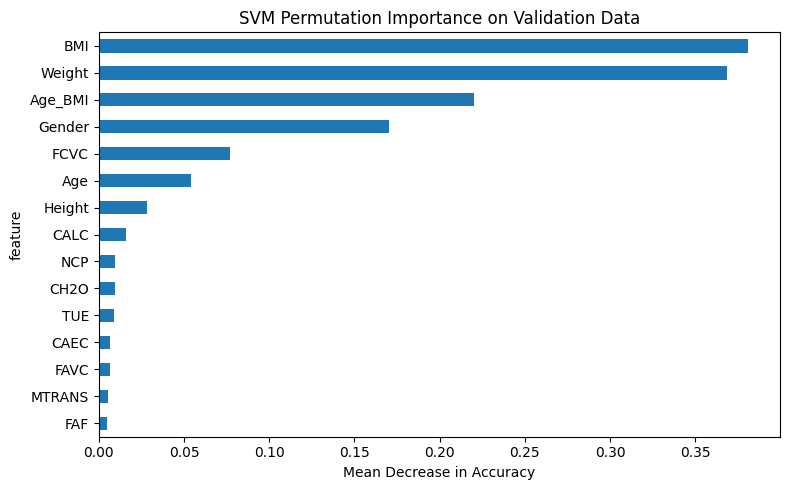

In [15]:
# 9.4 SVM interpretation using permutation importance on validation data
# This can take a few minutes. Reduce n_repeats if runtime is too high.
svm_pipe = fitted_models["Support Vector Machine"]

perm = permutation_importance(
    svm_pipe,
    X_valid,
    y_valid,
    scoring="accuracy",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(svm_importance)

fig, ax = plt.subplots(figsize=(8, 5))
svm_importance.head(15).sort_values("importance_mean").plot(
    kind="barh",
    x="feature",
    y="importance_mean",
    ax=ax,
    legend=False
)
ax.set_title("SVM Permutation Importance on Validation Data")
ax.set_xlabel("Mean Decrease in Accuracy")
plt.tight_layout()
plt.show()


## 10. Findings and Assumption Interpretation

The validation results show that the **Support Vector Machine (SVM)** is the strongest of the four required models, with **88.90% validation accuracy** and **88.19% mean cross-validation accuracy**. Multinomial logistic regression is the second-best model, with **87.19% validation accuracy** and **86.44% mean cross-validation accuracy**, followed by Linear Discriminant Analysis (LDA) at **84.10% validation accuracy** and Gaussian Naïve Bayes at **66.71% validation accuracy**. The SVM also has a higher training accuracy (**91.42%**) than cross-validation accuracy, which suggests mild overfitting, but its validation performance remains the best overall.

The confusion matrices show that the easiest classes to classify are **Obesity_Type_III**, **Obesity_Type_II**, and **Insufficient_Weight**. For the SVM model, Obesity_Type_III is almost perfectly classified, with **806 out of 809** validation cases correctly predicted, while Obesity_Type_II has **632 out of 650** correctly predicted and Insufficient_Weight has **475 out of 505** correctly predicted. The most difficult classes are the neighboring middle categories, especially **Overweight_Level_I** and **Overweight_Level_II**, where classification errors are more common because these groups are closer to adjacent weight-risk classes. For example, SVM correctly identifies **343 out of 485** Overweight_Level_I cases and **392 out of 504** Overweight_Level_II cases, with many errors moving between neighboring overweight, normal-weight, and obesity classes.

The assumption checks show that the required models should be interpreted carefully. Logistic regression is useful and interpretable, but the VIF results show strong multicollinearity among engineered and original body-size variables, especially **BMI (VIF = 165.38)**, **Weight (VIF = 130.76)**, **Age_BMI (VIF = 92.05)**, **Age (VIF = 32.42)**, and **Height (VIF = 15.20)**. This means coefficient direction and magnitude should not be interpreted in isolation when those variables are included together. LDA performs reasonably well, but its assumptions are only partially met: the Shapiro-Wilk checks show very small p-values for many numeric variables within classes, indicating non-normality, and the covariance log determinants vary substantially across classes, especially for Obesity_Type_III, suggesting unequal class covariance structures. Gaussian Naïve Bayes performs worst because its conditional-independence assumption is not realistic for this data; within-class maximum pairwise numeric correlations range from about **0.85 to 0.98**, indicating that several predictors remain strongly related even after conditioning on class.

The model interpretation results support the performance findings. SVM permutation importance identifies **BMI (0.3807)**, **Weight (0.3686)**, **Age_BMI (0.2200)**, **Gender (0.1706)**, **FCVC (0.0770)**, **Age (0.0542)**, and **Height (0.0281)** as the strongest predictors. This indicates that body-composition variables drive most of the predictive signal, while eating and lifestyle variables add supporting information. Overall, SVM provides the strongest predictive performance, logistic regression provides the clearest coefficient-based explanation, LDA offers a useful linear benchmark, and Gaussian Naïve Bayes is the weakest model because its independence assumption is substantially violated.


In [16]:
summary_text = """
The four required models were compared using stratified cross-validation and a stratified validation split. The Support Vector Machine was the best overall model, with 88.90% validation accuracy and 88.19% mean cross-validation accuracy. Multinomial logistic regression ranked second with 87.19% validation accuracy, followed by Linear Discriminant Analysis at 84.10% and Gaussian Naive Bayes at 66.71%. The SVM performed especially well on Obesity_Type_III, Obesity_Type_II, and Insufficient_Weight, but it still confused neighboring middle-risk classes such as Overweight_Level_I and Overweight_Level_II. The assumption checks show that logistic regression is interpretable but affected by strong multicollinearity among BMI, Weight, Age_BMI, Age, and Height; LDA is useful but its normality and equal-covariance assumptions are only partially met; and Naive Bayes performs weakest because the conditional-independence assumption is violated by strong within-class numeric correlations. SVM permutation importance confirms that BMI, Weight, Age_BMI, Gender, FCVC, Age, and Height carry the strongest predictive signal.
"""
print(summary_text)



The four required models were compared using stratified cross-validation and a stratified validation split. The Support Vector Machine was the best overall model, with 88.90% validation accuracy and 88.19% mean cross-validation accuracy. Multinomial logistic regression ranked second with 87.19% validation accuracy, followed by Linear Discriminant Analysis at 84.10% and Gaussian Naive Bayes at 66.71%. The SVM performed especially well on Obesity_Type_III, Obesity_Type_II, and Insufficient_Weight, but it still confused neighboring middle-risk classes such as Overweight_Level_I and Overweight_Level_II. The assumption checks show that logistic regression is interpretable but affected by strong multicollinearity among BMI, Weight, Age_BMI, Age, and Height; LDA is useful but its normality and equal-covariance assumptions are only partially met; and Naive Bayes performs weakest because the conditional-independence assumption is violated by strong within-class numeric correlations. SVM permut

## 11. Create Kaggle Submission

The submission uses the best validation model from the four required models. For a formal competition submission, download `submission.csv` and upload it to the Kaggle competition page.


In [17]:
best_model = fitted_models[best_model_name]

# Refit the chosen model on the full training data before predicting the Kaggle test set.
best_model.fit(X, y)
test_predictions = best_model.predict(X_test_final)

submission = sample_submission.copy()
submission[target_col] = test_predictions

display(submission.head())
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv using:", best_model_name)
print("Submission shape:", submission.shape)


,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


Saved submission.csv using: Support Vector Machine
Submission shape: (13840, 2)
